## Build a basic chatbot with Langgraph(Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:

class State(TypedDict):
    #TypedDict is a way in Python to specify the structure of a dictionary with types.
    #State is a dictionary-like object with a key "messages" that stores a list of messages.
    #Syntax: Annotated[Type, Metadata]
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
    

In [3]:

import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="openai/gpt-oss-120b")

In [5]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x129c0c890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x129f74950>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
llm=init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x129f77050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x129f77b50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
#invoke() is the method that sends input to the model and returns the output.
#Here, it is being passed the entire message history, i.e., state["messages"].
#Effectively, the model sees all previous messages to generate the next response
#The function returns a dictionary with a single key "messages".

In [8]:

graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

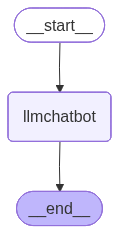

In [9]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:

response=graph.invoke({"messages":"Hi"})

In [11]:

response["messages"][-1].content

'Hello! How can I help you today?'

In [12]:
# for event in graph.stream({"messages":"Hi how are you"}):
#     for value in event.values():
#         print(value)
        
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thanks for asking. How can I help you today?


## Chatbot With Tool

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is langraph")

{'query': 'What is langraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decision-making by modelin

In [14]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools = [tool,multiply]

In [16]:
llm_with_tool = llm.bind_tools(tools)

In [17]:
llm_with_tool

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x129f77050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x129f77b50>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search

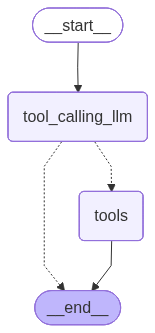

In [18]:

## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages":"what is the recent AI news"})


In [20]:
# response["messages"][-1]
response["messages"][-1].content

'{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/ai-today-in-5-march-5-2026-the-ai-s-02926/", "title": "AI Today in 5: March 5, 2026, The AI ‘s Biggest Test Edition | Thomas Fox - Compliance Evangelist - JD Supra", "score": 0.99942964, "published_date": "Thu, 05 Mar 2026 20:07:02 GMT", "content": "Welcome to AI Today in 5, the newest addition to the Compliance Podcast Network. Each day, Tom Fox will bring you 5 stories about AI to start your day. Sit back, enjoy a cup of morning coffee, and listen in to the AI Today In 5. All, from the Compliance Podcast Network. Each day, we consider five stories from the business world, compliance, ethics, risk management, leadership, or general interest about AI.\\nTop AI stories include:\\n\\n• Ending compliance bottlenecks with AI. See more+ [...] • Ending compliance bottlenecks with AI. See more+\\n\\nWelcome to AI Today in 5, the newest addit

In [21]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_2cef7af5-df5c-476a-84c0-996fc85319ba)
 Call ID: fc_2cef7af5-df5c-476a-84c0-996fc85319ba
  Args:
    query: latest AI news March 2026
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jdsupra.com/legalnews/ai-today-in-5-march-5-2026-the-ai-s-02926/", "title": "AI Today in 5: March 5, 2026, The AI ‘s Biggest Test Edition | Thomas Fox - Compliance Evangelist - JD Supra", "score": 0.99942964, "published_date": "Thu, 05 Mar 2026 20:07:02 GMT", "content": "Welcome to AI Today in 5, the newest addition to the Compliance Podcast Net

In [22]:
response = graph.invoke({"messages":"what is 2 multipled by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multipled by 3
================================== Ai Message ==================================

2 multiplied by 3 equals **6**.


In [23]:
response = graph.invoke({"messages":"what is 2 multiplied by 3 and then multiply 10 "})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3 and then multiply 10 
================================== Ai Message ==================================

\(2 \times 3 = 6\)

Then multiply that result by 10:

\(6 \times 10 = 60\)

So the final answer is **60**.


In [24]:
response = graph.invoke({"messages":"what is the recent AI news and 5 multiply by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and 5 multiply by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_afb57b0d-a974-457e-8a2a-c21112f97975)
 Call ID: fc_afb57b0d-a974-457e-8a2a-c21112f97975
  Args:
    query: AI news March 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.mean.ceo/ai-news-march-2026", "title": "AI News | March, 2026 (STARTUP EDITION)", "content": "Start lean: Most startups will benefit from no-code AI tools (e.g., Canva with AI features).\n   Test, but track: Emphasize experimental frameworks and align AI benefits to measurable KPIs.\n   Rethink your team: AI should play the role of productive co-founder 

### React Agent Architecture

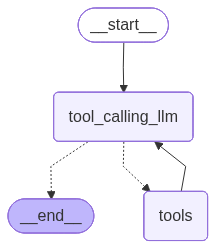

In [25]:
 
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
response = graph.invoke({"messages":"what is the recent AI news and 5 multiply by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and 5 multiply by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_d2207df0-b4c7-4021-9b3f-8dfac6598609)
 Call ID: fc_d2207df0-b4c7-4021-9b3f-8dfac6598609
  Args:
    query: latest AI news March 2026
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ctvnews.ca/video/2026/03/08/ctv-qp-all-options-are-on-the-table-for-protecting-canadians-from-ai-minister/", "title": "'All options are on the table' for protecting Canadians from AI: minister", "content": "... March 08, 2026 at 12:00PM EDT. Top Videos · Cambridge company creates new AI robot. March 08, 2026 at 11:33PM EDT. Canadian fossil cen

In [27]:
response = graph.invoke({"messages":"what is the recent AI news and 5 multiply by 2 and add 4 and 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news and 5 multiply by 2 and add 4 and 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_b139185f-c2d2-419f-8062-03ca04249ba9)
 Call ID: fc_b139185f-c2d2-419f-8062-03ca04249ba9
  Args:
    query: latest AI news March 2026
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news March 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ctvnews.ca/video/2026/03/08/ctv-qp-all-options-are-on-the-table-for-protecting-canadians-from-ai-minister/", "title": "'All options are on the table' for protecting Canadians from AI: minister", "content": "... March 08, 2026 at 12:00PM EDT. Top Videos · Cambridge company creates new AI robot. March 08, 2026 at 11:33PM EDT. Can

### Adding memory in Agentic Graph

In [28]:
response = graph.invoke({"messages":"Hello my name is Saara"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Saara
================================== Ai Message ==================================

Nice to meet you, Saara! How can I assist you today?


In [29]:
response = graph.invoke({"messages":"What is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don’t actually know your name—unless you’d like to share it, I can’t guess it. If you tell me, I’ll be happy to use it in our conversation!


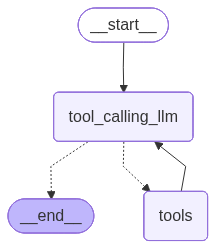

In [30]:
 
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")


## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
#If we want to use this specific memory for a previous interaction
# or if we want the context of the previous interaction, first of all we need to create
# a thread id.Because it will be related to one specific session
config = {"configurable": {"thread_id": "1"}}

In [32]:
response = graph.invoke({"messages": "Hi, my name is Saara"}, config=config)
response

{'messages': [HumanMessage(content='Hi, my name is Saara', additional_kwargs={}, response_metadata={}, id='5aea31a6-3224-4736-851d-08a516bb2ec0'),
  AIMessage(content='Hello Saara! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user just said "Hi, my name is Saara". Likely they want greeting. We can respond warmly, ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 349, 'total_tokens': 411, 'completion_time': 0.363574337, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.319781236, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.045652963, 'total_time': 0.683355573}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd1f4-90df-7942-ba34-8872727bf091-0', tool_calls=[], invalid_tool_calls=[], usage_

In [33]:
response = graph.invoke({"messages": "What's my name"}, config=config)
print(response["messages"][-1].content)

Your name is Saara.


In [34]:
response = graph.invoke({"messages": "Hey, do you remember my name?"}, config=config)
print(response["messages"][-1].content)

Yes, I remember—you’re Saara! Let me know if there’s anything specific you’d like to talk about or need help with.


In [35]:

config = {"configurable": {"thread_id": "2"}}
response = graph.invoke({"messages": "Hey, do you remember my name?"}, config=config)
print(response["messages"][-1].content)
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": "Hey, do you remember my name?"}, config=config)
print(response["messages"][-1].content)

I’m afraid I don’t have your name on record. Could you remind me what you’d like me to call you?
Absolutely—I’ve got it: your name is Saara. How can I help you today?


### Streaming

In [36]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [37]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

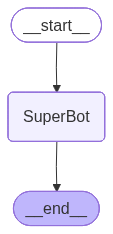

In [38]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer = memory)

##Display
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [39]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages":"Hi. my name is Saara and I like cricket"},config)


{'messages': [HumanMessage(content='Hi. my name is Saara and I like cricket', additional_kwargs={}, response_metadata={}, id='c5cbe137-2804-4bb6-a21d-5e277f941645'),
  AIMessage(content="Hey Saara! 👋 Nice to meet you. Cricket is such an exciting sport—whether it’s the strategic depth of a Test match or the fast‑paced thrills of a T20, there’s always something to love. \n\nDo you have a favorite team or player? Maybe you follow a particular league (IPL, BBL, CPL, etc.) or enjoy watching any specific formats? I'd love to hear more about what draws you to cricket! 🏏", additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi. my name is Saara and I like cricket". Probably respond friendly, ask about cricket preferences, etc. There\'s no disallowed content. So we can just chat.'}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 82, 'total_tokens': 230, 'completion_time': 0.318262269, 'completion_tokens_details': {'reasoning_tokens': 45}, '

### Streaming

Methods: .stream() and astream()

-These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

-values : This streams the full state of the graph after each node is called.
-updates : This streams updates to the state of the graph after each node is called.

In [40]:
# Create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Saara and I like Cricket"},config,stream_mode="updates"):
    print(chunk)

#gets the AI message only. Doesn't get the human message

{'SuperBot': {'messages': [AIMessage(content="Hi Saara! 👋 Nice to meet you. Cricket is such an exciting sport—there’s always something happening on the field. Do you have a favorite team or player you follow? Or maybe there’s a particular format (Test, ODI, T20) that you enjoy the most? I'd love to hear more!", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user introduced themselves: "Hi, My name is Saara and I like Cricket". Probably respond with greeting, ask about preferences, maybe ask about favorite team, etc. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 82, 'total_tokens': 203, 'completion_time': 0.261497074, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003214517, 'prompt_tokens_details': None, 'queue_time': 0.046477662, 'total_time': 0.264711591}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop

In [ ]:
# Create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Saara and I like Cricket"},config,stream_mode="updates"):
    print(chunk)

#gets the AI message only. Doesn't get the human message

{'messages': [HumanMessage(content='Hi, My name is Saara and I like Cricket', additional_kwargs={}, response_metadata={}, id='5fd24ade-9cee-4a5d-95c8-764433c1113d'), AIMessage(content="Hi Saara! 👋 Nice to meet you. Cricket is such an exciting sport—there’s always something happening on the field. Do you have a favorite team or player you follow? Or maybe there’s a particular format (Test, ODI, T20) that you enjoy the most? I'd love to hear more!", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user introduced themselves: "Hi, My name is Saara and I like Cricket". Probably respond with greeting, ask about preferences, maybe ask about favorite team, etc. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 82, 'total_tokens': 203, 'completion_time': 0.261497074, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003214517, 'prompt_tokens_details': None, 'queue_time': 0.046477662, 'total_time': 0.

In [42]:
# Create a thread
config = {"configurable": {"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Saara and I like football"},config,stream_mode="values"):
    print(chunk)
    
#gets the human message and AI Message is also appended,simply everything is getting displayed

{'messages': [HumanMessage(content='Hi, My name is Saara and I like football', additional_kwargs={}, response_metadata={}, id='ee58c406-c31c-4ffc-ac51-b04290147c3d')]}
{'messages': [HumanMessage(content='Hi, My name is Saara and I like football', additional_kwargs={}, response_metadata={}, id='ee58c406-c31c-4ffc-ac51-b04290147c3d'), AIMessage(content='Hi Saara! 👋 Nice to meet you. Football is such an exciting sport—do you have a favorite team or player? If you ever want to chat about matches, tactics, or anything else, I’m here!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Saara and I like football". Probably greet and ask about preferences. No disallowed content. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 82, 'total_tokens': 175, 'completion_time': 0.19607451, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.014679662, 'prompt_tokens_details': None, 'queue

In [ ]:

# Create a thread
config = {"configurable": {"thread_id": "7"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish! 👋 Nice to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching matches, playing yourself, or maybe both? Let me know if there’s anything specific you’d like to chat about (scores, history, tips, anything cricket‑related, or something else entirely). I'm here to help!", additional_kwargs={'reasoning_content': 'We need to respond. The user introduced themselves: "Hi, My name is Krish And I like cricket". Probably a greeting. Should respond politely, ask about cricket preferences, maybe ask how to help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 82, 'total_tokens': 217, 'completion_time': 0.293314178, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003161506, 'prompt_tokens_details': None, 'queue_time': 0.045894994, 'total_time': 0.296475684}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprin

In [48]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='94c14b72-9161-4a04-ae06-81ca2c3c56de'), AIMessage(content="Hello Krish! 👋 Nice to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching matches, playing yourself, or maybe both? Let me know if there’s anything specific you’d like to chat about (scores, history, tips, anything cricket‑related, or something else entirely). I'm here to help!", additional_kwargs={'reasoning_content': 'We need to respond. The user introduced themselves: "Hi, My name is Krish And I like cricket". Probably a greeting. Should respond politely, ask about cricket preferences, maybe ask how to help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 82, 'total_tokens': 217, 'completion_time': 0.293314178, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003161506, 'pr

In [51]:

# Create a thread
config = {"configurable": {"thread_id": "8"}}

async for event in graph_builder.astream_events({'messages':"Hi,My name is Saara And I like cricket"},config,version="v2"):
    print(chunk)
    
#more detailed info of different multiple events.much more detailed information

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='94c14b72-9161-4a04-ae06-81ca2c3c56de'), AIMessage(content="Hello Krish! 👋 Nice to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching matches, playing yourself, or maybe both? Let me know if there’s anything specific you’d like to chat about (scores, history, tips, anything cricket‑related, or something else entirely). I'm here to help!", additional_kwargs={'reasoning_content': 'We need to respond. The user introduced themselves: "Hi, My name is Krish And I like cricket". Probably a greeting. Should respond politely, ask about cricket preferences, maybe ask how to help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 82, 'total_tokens': 217, 'completion_time': 0.293314178, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003161506, 'pr